# Noisy MLP Heatmap

This notebook builds a simple `2 -> 32 -> 32 -> 1` PyTorch MLP, initializes it with random noise, and visualizes outputs as a heatmap over a 2D grid.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [54]:
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)


class SimpleMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            Sine(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim),
        )
        self._init_with_noise()

    def _init_with_noise(self, std=0.5):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=std)
                nn.init.normal_(module.bias, mean=0.0, std=std)

    def forward(self, x):
        return self.net(x)


model = SimpleMLP()
model.eval()

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Sine()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

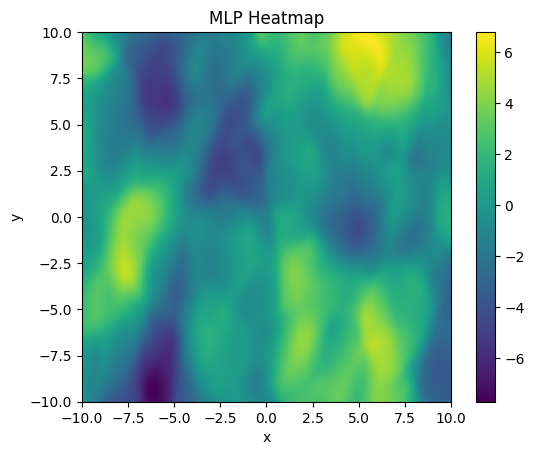

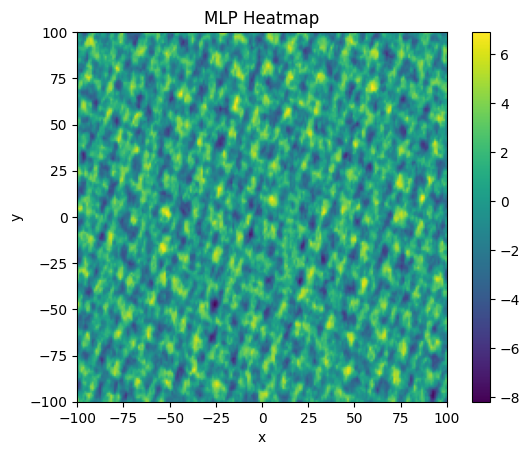

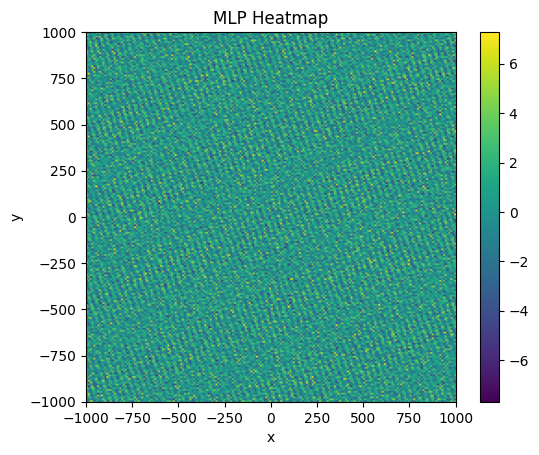

In [55]:
def plot_heatmap(model, x_range=(-10, 10), y_range=(-10, 10), resolution=100):
    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    xx, yy = np.meshgrid(x, y)
    grid = np.stack([xx.flatten(), yy.flatten()], axis=-1)
    with torch.no_grad():
        inputs = torch.from_numpy(grid).float()
        outputs = model(inputs).numpy().reshape(resolution, resolution)
    plt.imshow(
        outputs, extent=(x_range[0], x_range[1], y_range[0], y_range[1]), origin="lower"
    )
    plt.colorbar()
    plt.title("MLP Heatmap")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


plot_heatmap(model, x_range=(-10, 10), y_range=(-10, 10), resolution=200)
plot_heatmap(model, x_range=(-100, 100), y_range=(-100, 100), resolution=200)
plot_heatmap(model, x_range=(-1000, 1000), y_range=(-1000, 1000), resolution=200)